# STEP 4. 공원 간 각도 관계 계산 (simplest path 엔진)

**목적**: 모든 공원 쌍 $(i, j)$에 대해 attachment 세그먼트 사이의 **simplest path 각도 비용**을 계산한다. N1(angular few-turn)과 N3(few-turn field overlap)의 원자료가 된다.

$$A_{ij}(R) = \min_{u \in B^{src}_i,\ v \in B_j} \text{AngularCost}(u, v) \quad \text{s.t. simplest path 길이} \le R$$

**방법**
- 출발점 $u$마다 `NetworkStructure.dijkstra_tree_simplest(u, max_seconds=R_MAX, speed_m_s=1)` 호출(cityseer Rust). 반환된 `simpl_dist` = 누적 각도 변화(°), `agg_seconds` = 해당 simplest path의 길이(m, speed=1).
- 같은 출발점에서 `dijkstra_tree_shortest`도 호출해 **최단 네트워크 거리**를 얻는다. 거리 null model과 거리 구간 통제에 쓴다.
- **R은 탐색 한계로만 사용**: R_MAX = 3200 m로 한 번 탐색하고, "simplest path 길이 ≤ R" 조건으로 사후 필터링해 R ∈ {800, 1600, 3200}을 얻는다. (주의: cityseer simplest 탐색은 방향 상태마다 최소 각도 레이블 하나만 유지한다. 그래서 R 근처에서는 더 짧지만 각도가 큰 경로가 누락될 수 있어, R은 엄밀한 제약이 아니라 보수적 탐색 한계다.)
- 출발점 = 공원당 FPS 상위 K=8개 attachment, 도착점 = 모든 attachment. 대칭화는 STEP 6에서 한다.
- N3용으로 공원별 **angular catchment**(각도 ≤ θc, 길이 ≤ R)와 **metric catchment**(최단거리 ≤ R)도 저장한다.
- 보로 단위 체크포인트: 중간에 멈춰도 다시 실행하면 완료된 보로는 건너뛴다.

**출력**: `Data/derived/{AREA}/relations/segpairs_{v}_{b}.parquet`, `catch_{v}_{b}.pkl` → 집계 `pairs_{v}.parquet`, `catch_park_{v}.pkl`

In [1]:
# ===== 공통 설정 (모든 STEP 노트북에서 동일) =====
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# 분석 지역: "Brooklyn"(파일럿) 또는 "NYC"(전체). 환경변수 PARK_STUDY_AREA로도 지정 가능.
STUDY_AREA = os.environ.get("PARK_STUDY_AREA", "Brooklyn")

ROOT = Path.cwd()
DATA = ROOT / "Data"
PARKS_PATH = DATA / "NYCPark" / "Parks_Properties_20260923.geojson"
NET_DIR = DATA / "derived" / "network"        # STEP1 결과 (지역 무관, NYC+버퍼 전체)
AREA_DIR = DATA / "derived" / STUDY_AREA      # STEP2 이후 결과
OUT_DIR = ROOT / "outputs" / STUDY_AREA
for _d in (NET_DIR, AREA_DIR, OUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

CRS = 32618            # UTM 18N (m)
R_MAX = 3200           # 탐색 한계 (m) = 보로 네트워크 버퍼 폭
SPEED = 1.0            # speed_m_s=1 -> agg_seconds == 경로 길이(m)

BOROUGHS = {"M": "Manhattan", "X": "Bronx", "B": "Brooklyn", "Q": "Queens", "R": "Staten Island"}
AREA_BOROUGHS = ["B"] if STUDY_AREA == "Brooklyn" else list(BOROUGHS)

# 네트워크 변형: C = 가로 중심선 + 보행전용 경로 (주 분석), S = 보도 포함 전체 보행망 (민감도)
VARIANTS = ["C", "S"]
PRIMARY = "C"
SIDEWALK_FOOTWAYS = {"sidewalk", "crossing", "traffic_island"}

# 공원 필터 (사용자 결정): Flagship + 비공원성 필지 제외, 면적 상한 100 acres (계산은 200 상위집합)
EXCLUDE_TYPES = ["Flagship Park", "Operations", "Lot", "Undeveloped",
                 "Buildings/Institutions", "Cemetery", "Managed Sites"]
AREA_CAP = 100
AREA_CAP_SUPERSET = 200
AREA_CAP_GRID = [50, 100, 200]
RESTRICTED_TYPES = ["Garden", "Jointly Operated Playground"]            # 접근 제한 민감도
STREET_EMBEDDED_TYPES = ["Triangle/Plaza", "Strip", "Mall", "Parkway"]  # 가로 매몰형 민감도

# 공원-네트워크 attachment
ATTACH_BUFFER = {"C": 20.0, "S": 10.0}   # 경계 버퍼 (m): C는 중심선이 도로 폭 절반만큼 떨어져 있음
ATTACH_BUFFER_GRID = {"C": [15.0, 20.0, 30.0], "S": [5.0, 10.0, 20.0]}
INSIDE_SHARE = 0.9       # 공원 내부에 90% 이상 들어간 세그먼트는 attachment에서 제외 (통행은 허용)
K_SOURCES = 8            # 공원당 출발 attachment 최대 개수 (farthest-point sampling)
SMALL_COMPONENT = 200    # 이보다 작은 연결요소에만 붙은 공원은 'unresolved'

# N1 angular few-turn
N1_THETAS = [15, 45, 90, 180]
N1_RADII = [800, 1600, 3200]
N1_REL_Q = [0.1, 0.2]
DIST_BANDS = [0, 200, 400, 800, 1600, 3200]

# N2 configurational corridor
N2_RADII = [800, 1600, 3200]
N2_TOP_P = [0.02, 0.05, 0.10]
STROKE_ANGLE = 30
STROKE_ANGLE_GRID = [20, 30, 45]
N2_MAX_ALONG = [3200, None]

# N3 excess few-turn field overlap
N3_THETAS = [45, 90]
N3_RADII = [800, 1600]
N3_TAU = [0.1, 0.2]
N3_KAPPA = [1.0, 1.25]

print(f"STUDY_AREA={STUDY_AREA}  boroughs={AREA_BOROUGHS}  AREA_DIR={AREA_DIR.relative_to(ROOT)}")

STUDY_AREA=NYC  boroughs=['M', 'X', 'B', 'Q', 'R']  AREA_DIR=Data/derived/NYC


In [2]:
import pickle
import logging
from cityseer.network import CityNetwork
import matplotlib.pyplot as plt

logging.getLogger("cityseer").setLevel(logging.WARNING)
CN_DIR = NET_DIR / "cityseer"
REL_DIR = AREA_DIR / "relations"
REL_DIR.mkdir(exist_ok=True)

parks = gpd.read_parquet(NET_DIR / "parks.parquet")
att = pd.read_parquet(NET_DIR / "attachments.parquet")
D_GRID_RUN = STUDY_AREA == "Brooklyn"          # attachment 버퍼 d 민감도는 파일럿에서만
N3_CFGS = [(t, r) for t in N3_THETAS for r in N3_RADII]
print("focal parks:", int(parks.borough.isin(AREA_BOROUGHS).sum()), "| d-grid sources:", D_GRID_RUN)


def global_codes(v):
    s = pd.read_parquet(NET_DIR / f"segments_{v}.parquet", columns=["seg_id", "length"])
    return pd.Series(np.arange(len(s), dtype=np.int32), index=s["seg_id"].values), s["length"].values.astype(np.float32)


CODES = {v: global_codes(v) for v in VARIANTS}
att["seg_code"] = -1
for v in VARIANTS:
    m = att.variant == v
    att.loc[m, "seg_code"] = CODES[v][0].reindex(att.loc[m, "seg_id"]).values
att["seg_code"] = att["seg_code"].astype(np.int32)

focal parks: 1929 | d-grid sources: False


## 4-1. 보로별 실행 함수

In [3]:
def run_borough(v, b):
    f_pairs, f_catch = REL_DIR / f"segpairs_{v}_{b}.parquet", REL_DIR / f"catch_{v}_{b}.pkl"
    if f_pairs.exists() and f_catch.exists():
        print(f"[{v}/{b}] cached")
        return None
    t0 = time.time()
    cn = CityNetwork.load(CN_DIR / f"cn_{v}_{b}")
    ns, ng = cn.network_structure, cn.nodes_gdf
    bound = int(ng["ns_node_idx"].max()) + 1
    nidx = ng["ns_node_idx"]
    code_by_nidx = np.full(bound, -1, dtype=np.int32)
    code_by_nidx[nidx.values] = CODES[v][0].reindex(ng.index).values

    a = att[(att.variant == v) & att.seg_id.isin(ng.index)]
    focal = a.park_id.isin(parks.index[parks.borough == b])
    src_mask = focal & (a.fps_rank < K_SOURCES) & (a.is_default | D_GRID_RUN)
    src_segs = a.loc[src_mask, "seg_id"].unique()
    n3_src = set(a.loc[focal & a.is_default & (a.fps_rank < K_SOURCES), "seg_id"])
    is_tgt = np.zeros(bound, dtype=bool)
    is_tgt[nidx.reindex(a.seg_id.unique()).values] = True
    t_load = time.time() - t0
    print(f"[{v}/{b}] nodes={bound:,} sources={len(src_segs):,} (N3 {len(n3_src):,}) "
          f"targets={int(is_tgt.sum()):,} load={t_load:.0f}s")

    chunks, catch = [], {}
    simpl_full = np.full(bound, np.inf, dtype=np.float32)
    alen_full = np.full(bound, np.inf, dtype=np.float32)
    sd_full = np.full(bound, np.inf, dtype=np.float32)
    log = REL_DIR / "progress.log"
    t_loop = time.time()
    for k, s in enumerate(src_segs):
        if k % 500 == 0:
            with open(log, "a") as fh:
                fh.write(f"{time.strftime('%H:%M:%S')} {v}/{b} {k}/{len(src_segs)} "
                         f"({time.time() - t_loop:.0f}s)\n")
        u = int(nidx[s])
        vis, tree = ns.dijkstra_tree_simplest(u, int(R_MAX), SPEED)
        vis = np.asarray(vis, dtype=np.int64)
        simpl_all = np.fromiter((tree[t].simpl_dist for t in vis), np.float32, len(vis))
        alen_all = np.fromiter((tree[t].agg_seconds for t in vis), np.float32, len(vis))
        del tree
        visS, treeS = ns.dijkstra_tree_shortest(u, int(R_MAX), SPEED)
        visS = np.asarray(visS, dtype=np.int64)
        sd_all = np.fromiter((treeS[t].short_dist for t in visS), np.float32, len(visS))
        del treeS

        simpl_full[vis], alen_full[vis], sd_full[visS] = simpl_all, alen_all, sd_all
        tg = np.union1d(vis[is_tgt[vis]], visS[is_tgt[visS]])
        chunks.append(pd.DataFrame({
            "src": np.int32(code_by_nidx[u]), "tgt": code_by_nidx[tg],
            "simpl": simpl_full[tg], "alen": alen_full[tg], "sd": sd_full[tg]}))
        simpl_full[vis] = np.inf; alen_full[vis] = np.inf; sd_full[visS] = np.inf

        if s in n3_src:
            c = {}
            for th, r in N3_CFGS:
                c[("ang", th, r)] = code_by_nidx[vis[(simpl_all <= th) & (alen_all <= r)]]
            for r in N3_RADII:
                c[("met", r)] = code_by_nidx[visS[sd_all <= r]]
            catch[int(code_by_nidx[u])] = c

    sp = pd.concat(chunks, ignore_index=True)
    sp.to_parquet(f_pairs)
    with open(f_catch, "wb") as fh:
        pickle.dump(catch, fh)
    el = time.time() - t0
    stat = dict(variant=v, borough=b, nodes=bound, sources=len(src_segs), rows=len(sp),
                total_s=round(el), sec_per_source=round((el - t_load) / max(len(src_segs), 1), 3))
    print(stat)
    return stat

## 4-2. 실행 (변형 × 보로)

In [4]:
run_stats = []
for v in VARIANTS:
    for b in AREA_BOROUGHS:
        st = run_borough(v, b)
        if st:
            run_stats.append(st)
if run_stats:
    pd.DataFrame(run_stats).to_csv(REL_DIR / f"run_stats_{int(time.time())}.csv", index=False)
    display(pd.DataFrame(run_stats))

Parsing geometries:   0%|          | 0/145259 [00:00<?, ?it/s]

Parsing geometries:   4%|▍         | 6019/145259 [00:00<00:02, 60177.86it/s]

Parsing geometries:   8%|▊         | 12037/145259 [00:00<00:02, 59292.95it/s]

Parsing geometries:  12%|█▏        | 17968/145259 [00:00<00:02, 58302.31it/s]

Parsing geometries:  16%|█▋        | 23800/145259 [00:00<00:02, 58129.24it/s]

...

Building edges:  99%|█████████▉| 303547/305835 [00:06<00:00, 48606.85it/s]

Building edges: 100%|██████████| 305835/305835 [00:06<00:00, 44442.70it/s]

[S/R] nodes=140,130 sources=807 (N3 807) targets=5,380 load=21s


{'variant': 'S', 'borough': 'R', 'nodes': 140130, 'sources': 807, 'rows': 487631, 'total_s': 81, 'sec_per_source': 0.075}


,variant,borough,nodes,sources,rows,total_s,sec_per_source
0,C,M,145259,2136,5755891,149,0.062
1,C,X,100708,1976,3402026,75,0.032
2,C,B,166522,3427,5422964,242,0.065
3,C,Q,246903,2881,2492424,285,0.089
4,C,R,84018,861,397275,45,0.039
5,S,M,300196,2176,10227855,554,0.233
6,S,X,184748,1933,6322759,233,0.107
7,S,B,408322,3629,11987758,1171,0.307
8,S,Q,529229,2871,4637867,1040,0.331
9,S,R,140130,807,487631,81,0.075


## 4-3. 공원 쌍 단위 집계
방향 $i \to j$ 레코드 (출발 = $i$의 FPS 상위 K 세그먼트, 도착 = $B_j$ 전체):
- `A_{R}`: 길이 ≤ R인 simplest path 중 최소 각도 비용
- `n_ok_{θ}_{R}`: 각도 ≤ θ, 길이 ≤ R을 만족하는 attachment 쌍 수 → 중복 연결 비율 $\rho = n_{ok} / (|B^{src}_i| \cdot |B_j|)$
- `D_net`: 최단 네트워크 거리(모든 attachment 쌍 중 최소)

설정(`cfg`): 기본 `d{d}_K8`, 출발점 수 민감도 `d{d}_K4`, 파일럿에서는 d 격자 추가.

In [5]:
def load_segpairs(v):
    return pd.concat([pd.read_parquet(REL_DIR / f"segpairs_{v}_{b}.parquet") for b in AREA_BOROUGHS],
                     ignore_index=True)


def park_pairs(sp, v, d, K):
    a = att[(att.variant == v) & (att.d == d)]
    src = a[a.fps_rank < K][["park_id", "seg_code"]].rename(columns={"park_id": "i", "seg_code": "src"})
    tgt = a[["park_id", "seg_code"]].rename(columns={"park_id": "j", "seg_code": "tgt"})
    m = sp.merge(src, on="src").merge(tgt, on="tgt")
    m = m[m.i != m.j]
    g = m.groupby(["i", "j"], sort=False)
    out = pd.DataFrame({"D_net": g["sd"].min()})
    for r in N1_RADII:
        ok_r = m["alen"] <= r
        out[f"A_{r}"] = m[ok_r].groupby(["i", "j"])["simpl"].min()
        out[f"len_{r}"] = m[ok_r].sort_values("simpl").groupby(["i", "j"])["alen"].first()
        for th in N1_THETAS:
            out[f"n_ok_{th}_{r}"] = m[ok_r & (m["simpl"] <= th)].groupby(["i", "j"]).size()
    out = out.reset_index()
    ok_cols = [c for c in out.columns if c.startswith("n_ok_")]
    out[ok_cols] = out[ok_cols].fillna(0).astype(np.int32)
    n_src = src.groupby("i").size()
    n_tgt = tgt.groupby("j").size()
    out["n_src"] = out["i"].map(n_src).astype(np.int32)
    out["n_tgt"] = out["j"].map(n_tgt).astype(np.int32)
    return out


for v in VARIANTS:
    sp = load_segpairs(v)
    d0 = ATTACH_BUFFER[v]
    cfgs = [(d0, K_SOURCES), (d0, 4)]
    if D_GRID_RUN:
        cfgs += [(d, K_SOURCES) for d in ATTACH_BUFFER_GRID[v] if d != d0]
    res = []
    for d, K in cfgs:
        pp = park_pairs(sp, v, d, K)
        pp.insert(0, "cfg", f"d{int(d)}_K{K}")
        res.append(pp)
        print(f"[{v}] d={d} K={K}: {len(pp):,} directed park pairs within R_MAX")
    pd.concat(res, ignore_index=True).to_parquet(AREA_DIR / f"pairs_{v}.parquet")
    del sp

[C] d=20.0 K=8: 184,237 directed park pairs within R_MAX


[C] d=20.0 K=4: 183,453 directed park pairs within R_MAX


[S] d=10.0 K=8: 183,125 directed park pairs within R_MAX


[S] d=10.0 K=4: 182,502 directed park pairs within R_MAX


## 4-4. 공원별 catchment 집계 (N3용)

In [6]:
for v in VARIANTS:
    per_src = {}
    for b in AREA_BOROUGHS:
        with open(REL_DIR / f"catch_{v}_{b}.pkl", "rb") as fh:
            per_src.update(pickle.load(fh))
    a = att[(att.variant == v) & att.is_default & (att.fps_rank < K_SOURCES) & att.seg_code.isin(list(per_src))]
    out = {}
    for pid, codes in a.groupby("park_id")["seg_code"]:
        keys = per_src[int(codes.iloc[0])].keys()
        out[pid] = {k: np.unique(np.concatenate([per_src[int(c)][k] for c in codes])) for k in keys}
    with open(AREA_DIR / f"catch_park_{v}.pkl", "wb") as fh:
        pickle.dump(out, fh)
    print(f"[{v}] catchments for {len(out):,} parks")

[C] catchments for 1,918 parks


[S] catchments for 1,902 parks


## 4-5. 요약: 각도 비용과 거리의 관계 (진단)
N1이 거리 네트워크로 환원되는지 알아보기 위한 첫 진단이다. 같은 거리 구간 안에서 각도 비용 분포가 넓게 퍼져 있다면 각도 관계가 거리와 독립적인 정보를 담고 있다는 뜻이다.

Spearman(A_3200, D_net) = 0.549  (n=168,471)


,count,mean,std,min,10%,25%,50%,75%,90%,max
band,,,,,,,,,,
"(0, 200]",2213.0,49.5,55.6,0.0,0.1,1.0,19.4,90.4,109.5,340.8
"(200, 400]",4459.0,101.2,69.8,0.0,3.8,64.4,92.6,141.8,184.4,591.8
"(400, 800]",13302.0,139.0,81.9,0.1,46.8,92.5,117.5,183.9,230.0,701.6
"(800, 1600]",39634.0,195.0,101.2,0.3,94.9,117.0,186.3,242.5,321.0,901.3
"(1600, 3200]",108087.0,309.4,174.9,1.1,130.7,196.1,275.0,381.2,514.3,2910.9


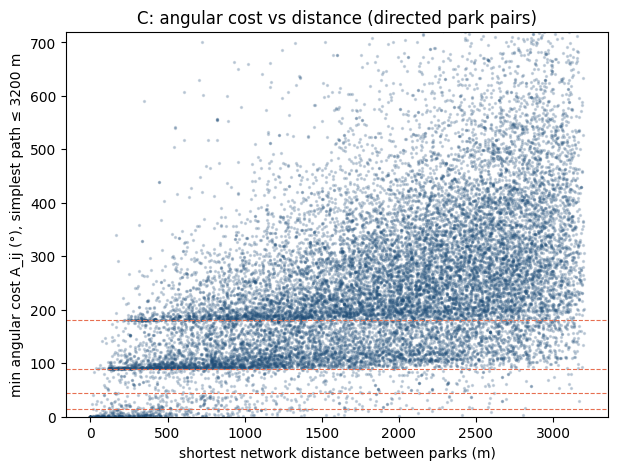

In [7]:
pp = pd.read_parquet(AREA_DIR / f"pairs_{PRIMARY}.parquet")
pp = pp[pp.cfg == f"d{int(ATTACH_BUFFER[PRIMARY])}_K{K_SOURCES}"]
pp = pp[pp.i.isin(parks.index[parks.in_main]) & pp.j.isin(parks.index[parks.in_main])]
pp["band"] = pd.cut(pp["D_net"], DIST_BANDS)
from scipy.stats import spearmanr
ok = pp["A_3200"].notna() & pp["D_net"].notna()
rho, _ = spearmanr(pp.loc[ok, "A_3200"], pp.loc[ok, "D_net"])
print(f"Spearman(A_3200, D_net) = {rho:.3f}  (n={ok.sum():,})")
display(pp.groupby("band", observed=True)["A_3200"].describe(percentiles=[.1, .25, .5, .75, .9]).round(1))

fig, ax = plt.subplots(figsize=(7, 5))
sub = pp[ok].sample(min(ok.sum(), 20000), random_state=0)
ax.scatter(sub["D_net"], sub["A_3200"], s=2, alpha=0.2, color="#1f4e79")
for th in N1_THETAS:
    ax.axhline(th, color="#e76f51", lw=0.8, ls="--")
ax.set_xlabel("shortest network distance between parks (m)")
ax.set_ylabel("min angular cost A_ij (°), simplest path ≤ 3200 m")
ax.set_title(f"{PRIMARY}: angular cost vs distance (directed park pairs)")
ax.set_ylim(0, 720)
plt.show()

## 4-6. 시각 확인: 한 공원에서 본 각도 장(angular field)
한 공원의 출발 attachment에서 모든 세그먼트까지의 최소 각도 비용이다. 0–15°(직진)는 짙은 색, 180° 이상은 옅은 색이다. 어떤 공원들이 "적은 회전으로" 닿는지 직관적으로 확인할 수 있다.

Parsing geometries:   0%|          | 0/145259 [00:00<?, ?it/s]

Parsing geometries:   5%|▌         | 7690/145259 [00:00<00:01, 76890.72it/s]

Parsing geometries:  11%|█         | 15380/145259 [00:00<00:01, 75900.14it/s]

Parsing geometries:  16%|█▌        | 22971/145259 [00:00<00:01, 75347.39it/s]

Parsing geometries:  21%|██        | 30655/145259 [00:00<00:01, 75927.63it/s]

...

Building edges:  97%|█████████▋| 664126/682211 [00:12<00:00, 56167.96it/s]

Building edges:  98%|█████████▊| 669922/682211 [00:12<00:00, 56700.25it/s]

Building edges:  99%|█████████▉| 675909/682211 [00:12<00:00, 57645.08it/s]

Building edges: 100%|█████████▉| 681743/682211 [00:12<00:00, 57850.86it/s]

Building edges: 100%|██████████| 682211/682211 [00:12<00:00, 54428.59it/s]

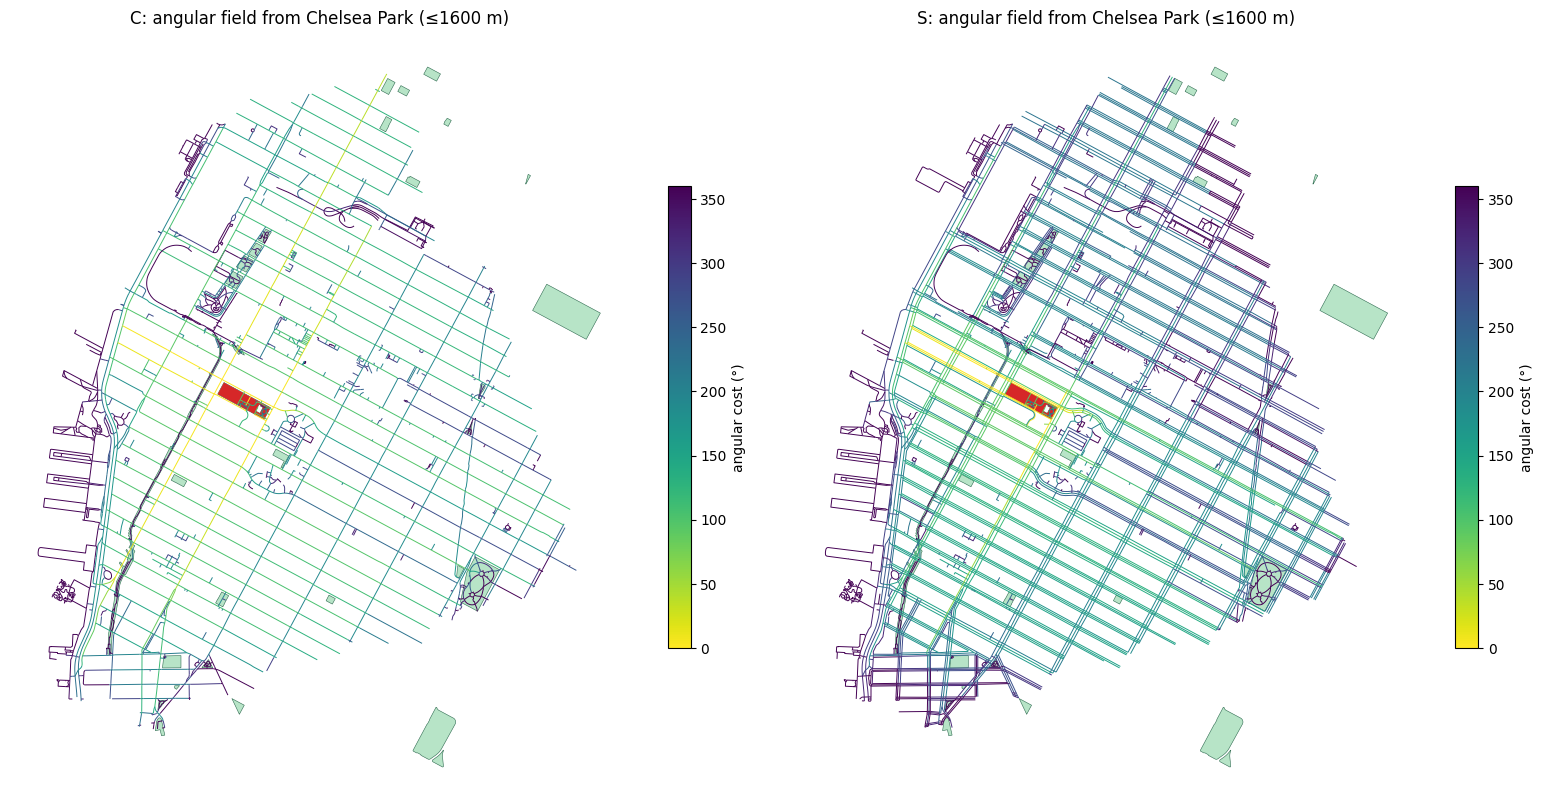

In [8]:
b0 = AREA_BOROUGHS[0]
focus = parks[(parks.borough == b0) & parks.in_main].sort_values("acres").iloc[-40]
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, v in zip(axes, VARIANTS):
    cn = CityNetwork.load(CN_DIR / f"cn_{v}_{b0}")
    ns, ng = cn.network_structure, cn.nodes_gdf
    srcs = att[(att.variant == v) & att.is_default & (att.park_id == focus.park_id) & (att.fps_rank < K_SOURCES)]
    best = np.full(int(ng.ns_node_idx.max()) + 1, np.inf)
    for s in srcs.seg_id:
        if s not in ng.index:
            continue
        vis, tree = ns.dijkstra_tree_simplest(int(ng.loc[s, "ns_node_idx"]), 1600, SPEED)
        for t in vis:
            best[t] = min(best[t], tree[t].simpl_dist)
    g = cn.to_geopandas()
    g["ang"] = best[g["ns_node_idx"].values]
    g = g[np.isfinite(g["ang"])]
    g.plot(ax=ax, column=np.clip(g["ang"], 0, 360), cmap="viridis_r", linewidth=0.7, legend=True,
           legend_kwds={"label": "angular cost (°)", "shrink": 0.6})
    near = parks[parks.intersects(g.union_all().envelope)]
    near.plot(ax=ax, color="#b7e4c7", edgecolor="#2d6a4f", linewidth=0.4)
    gpd.GeoSeries([focus.geometry], crs=CRS).plot(ax=ax, color="#d62728")
    ax.set_title(f"{v}: angular field from {focus['name']} (≤1600 m)")
    ax.set_axis_off()
    del cn, ns
plt.tight_layout()
plt.show()